In [1]:
from utils import *

In [ ]:
def plotMetrics(metrics):
    nodeX, nodeY = np.zeros([len(metrics), 4]), np.zeros([len(metrics), 4])
    precisionBox, recallBox, f1Box = np.zeros([len(metrics), config.future, 4]), np.zeros([len(metrics), config.future, 4]), np.zeros([len(metrics), config.future, 4])
    for i, name in enumerate(metrics):
        nodeX[i, :] = metrics[name]["nodes"].cpu().numpy()

        tp = metrics[name]["tp"]
        fp = metrics[name]["fp"]
        fn = metrics[name]["fn"]

        recall = tp / (tp + fn)
        precision = tp / (tp + fp)

        f1 = 2 * recall * precision / (recall + precision)

        nodeY[i, :] = torch.mean(f1, dim=0).cpu().numpy()

        precisionBox[i] = precision.cpu().numpy()
        recallBox[i] = recall.cpu().numpy()
        f1Box[i] = f1.cpu().numpy()

    plt.figure(figsize=(20, 12))

    labels = ["1 Year Return Period", "2 Year Return Period", "5 Year Return Period", "10 Year Return Period"]
    colors = ["blue", "green", "yellow", "orange"]
    for i in range(4):
        plt.subplot(2, 4, i + 1)
        plt.title(labels[i])
        currentX = nodeX[:, i]
        currentY = nodeY[:, i]
        mask = ~np.isnan(currentY)
        currentX, currentY = currentX[mask], currentY[mask]
        plt.scatter(currentX, currentY, alpha=0.3, c=colors[i])

        plt.grid()
        plt.xlabel("Total Upstream Basin Nodes")
        plt.ylabel("F1 Score")

    for i in range(4):
        plt.subplot(2, 4, i + 5)
        plt.title(labels[i])
        currentF1 = f1Box[:, :, i].T
        currentF1 = [box[~np.isnan(box)] for box in currentF1]
        plt.boxplot(currentF1)

        plt.grid()
        plt.xlabel("Forecast Horizon")
        plt.ylabel("F1 Score")

    plt.show()

    # [basins, 1], [basins, timesteps]
    nodeErrorX, nodeErrorY = np.array([metrics[name]["nodes"].cpu().numpy() for name in metrics]), np.array([metrics[name]["mae"].cpu().numpy() for name in metrics])
    plt.figure(figsize=(20, 6))
    for i in range(config.future):
        plt.subplot(1, config.future, i + 1)
        plt.scatter(nodeErrorX, nodeErrorY[:, i])
        plt.title(f"NMAE @ Horizon {i + 1}")
        plt.xlabel("Graph Size (# of Nodes)")
        if i == 0:
            plt.ylabel("NMAE")
        plt.grid()
    plt.show()
    
    nse = 1 - np.array([metrics[name]["nseNum"].cpu().numpy() / metrics[name]["nseDenom"].cpu().numpy() for name in metrics])
    cdf = np.array([np.sum(nse < (threshold / 1000)) / len(nse) for threshold in range(1000)])

    plt.figure(figsize=(12, 6))
    plt.plot(np.arange(1000)/1000, cdf)
    plt.title("Cumulative Distribution of NSE")
    plt.xlabel("NSE")
    plt.ylabel("CDF")
    plt.grid()
    plt.show()

    plt.figure(figsize=(12, 6))
    plt.hist(nse)
    plt.title("NSE Distribution")
    plt.xlabel("NSE")
    plt.ylabel("Frequency")
    plt.grid()
    plt.show()

    plt.figure(figsize=(12, 6))
    plt.scatter(nodeErrorX, nse)
    plt.title("NSE by Nodes")
    plt.xlabel("Graph Size (# of Nodes)")
    plt.ylabel("NSE")
    plt.grid()
    plt.show()


In [8]:
def evalModel(config, model, test):
    model.eval()

    metrics = {}

    progress = 0

    with torch.no_grad():
        try:
            for inputs, targets in test:
                history, future = targets.dischargeHistory, targets.dischargeFuture
                thresholds, means, deviations = targets.thresholds, targets.mean.unsqueeze(-1), targets.deviation.unsqueeze(-1)
                hindcast, forecast = model(inputs)

                # Consider sampling?
                medianPrediction = CMAL.median(forecast)
                mae = torch.abs(medianPrediction - future)

                nsePred = medianPrediction
                nseObs = future

                nseNumer = torch.sum(torch.pow(nseObs - nsePred, 2))
                nseDenom = torch.sum(torch.pow(nseObs - means, 2))

                medianPrediction = medianPrediction.unsqueeze(-1)
                future = future.unsqueeze(-1)
                thresholds = thresholds.unsqueeze(1).expand(-1, config.future, -1)
                tp = (medianPrediction > thresholds).float() * (future > thresholds).float()
                fp = (medianPrediction > thresholds).float() * (future < thresholds).float()
                fn = (medianPrediction < thresholds).float() * (future > thresholds).float()

                past, _ = inputs
                for n, name in enumerate(past.grdcID):
                    if name not in metrics:
                        metrics[name] = {
                            "iter": 0,
                            "mae": torch.zeros([config.future]),
                            "tp": torch.zeros([config.future, thresholds.shape[-1]]),
                            "fp": torch.zeros([config.future, thresholds.shape[-1]]),
                            "fn": torch.zeros([config.future, thresholds.shape[-1]]),
                            "nodes": past.nodes[n],
                            "nseNum": 0,
                            "nseDenom": 0,
                            "size": None
                        }

                    metrics[name]["mae"] = (metrics[name]["mae"] * metrics[name]["iter"] + mae[n]) / (metrics[name]["iter"] + 1)
                    metrics[name]["tp"] += tp[n]
                    metrics[name]["fp"] += fp[n]
                    metrics[name]["fn"] += fn[n]
                    metrics[name]["nseNum"] += nseNumer
                    metrics[name]["nseDenom"] += nseDenom
                    metrics[name]["iter"] += 1

                progress += 1
                print(f"\r{progress}/{len(test)} | {(progress / len(test)) * 100:.2f}% Complete", end="")

                if progress % 200 == 0:
                    plotMetrics(metrics)

        except KeyboardInterrupt:
            pass

        plotMetrics(metrics)

    # TODO: Evaluate on more stratified data (other continents?)
    # TODO: Maybe evaluate at New Madrid for fun

Loading GeoPandas...
GeoPandas Loaded
2543/2544 GRDC files loaded (4.0, 399.35427865947133)1.0)888671875)))))
9640/9640 ERA5 files loaded
Total empty basins: 37
57622/57646 Basin Structures Appended to Graph
Upstream Basins Compiled | 1.0 | 17.43485477178423
Upstream Structures Compiled
Structure Tensors Complete
45800.0
7705.3
5317.3
3160.0
7860.0
6842.0
34162.1
2929.3
57500.0
-999.0
-999.0
-999.0
-999.0
-999.0
2230.0
135.0
614.0
308.0
6230.0
9710.0
1210.0
2000.0
3290.0
1690.0
45600.0
126000.0
446.0
124397.7
1750.8
92722.0
3626.0
25800.0
23086.0
2964255.0
1870.0
2408.7
3680.0
5281.0
8883.7
7456.6
7042.2
76560.4
2978.5
1835274.0
448.1
2442.4
2043.5
141.4
243.5
10202.0
108521.0
4584.3
11111.1
6370.0
5880.0
1929.5
13183.0
4780.0
47.4
20927.2
20593.0
5444.2
1253819.0
2776.5
20914.3
16394.7
36358.4
1502.2
6972.3
16923.1
59.311
5931.1
541.3
7327.1
134.4
217.6
4529.9
3680.4
4889.9
2553.7
1012.7
5460.0
1225.1
10152.8
1129.2
8572.9
179.0
363.0
166.0
73000.0
54900.0
1230.0
4400.0
764.0
289562.0

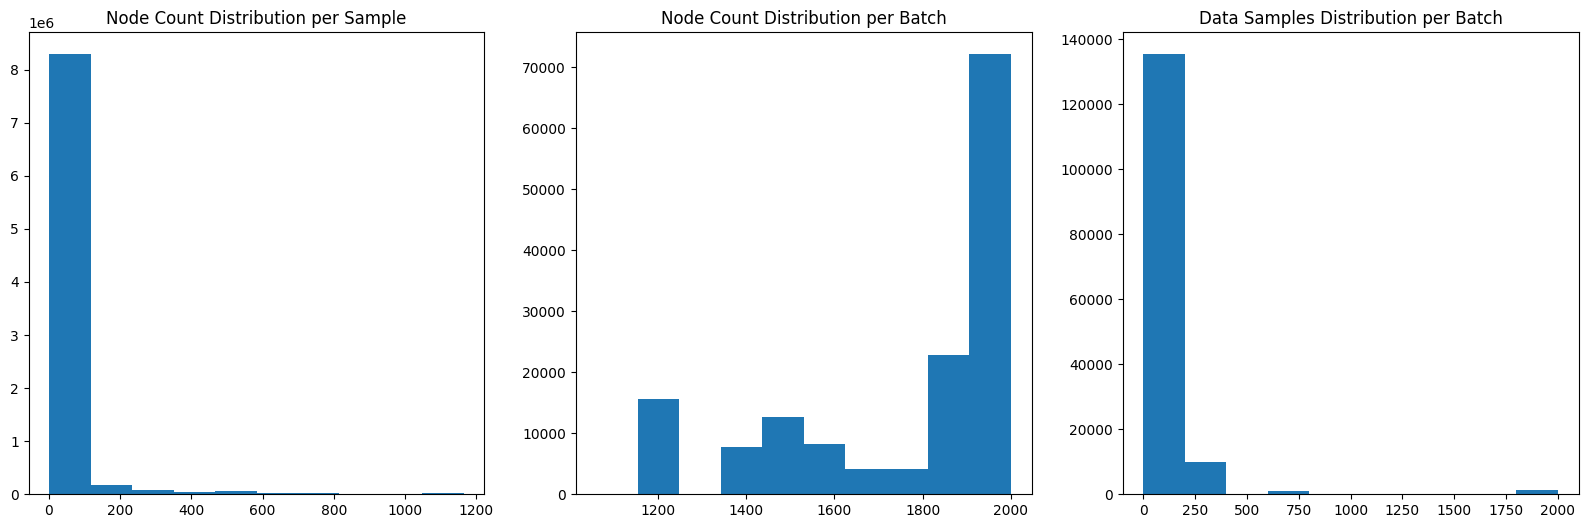

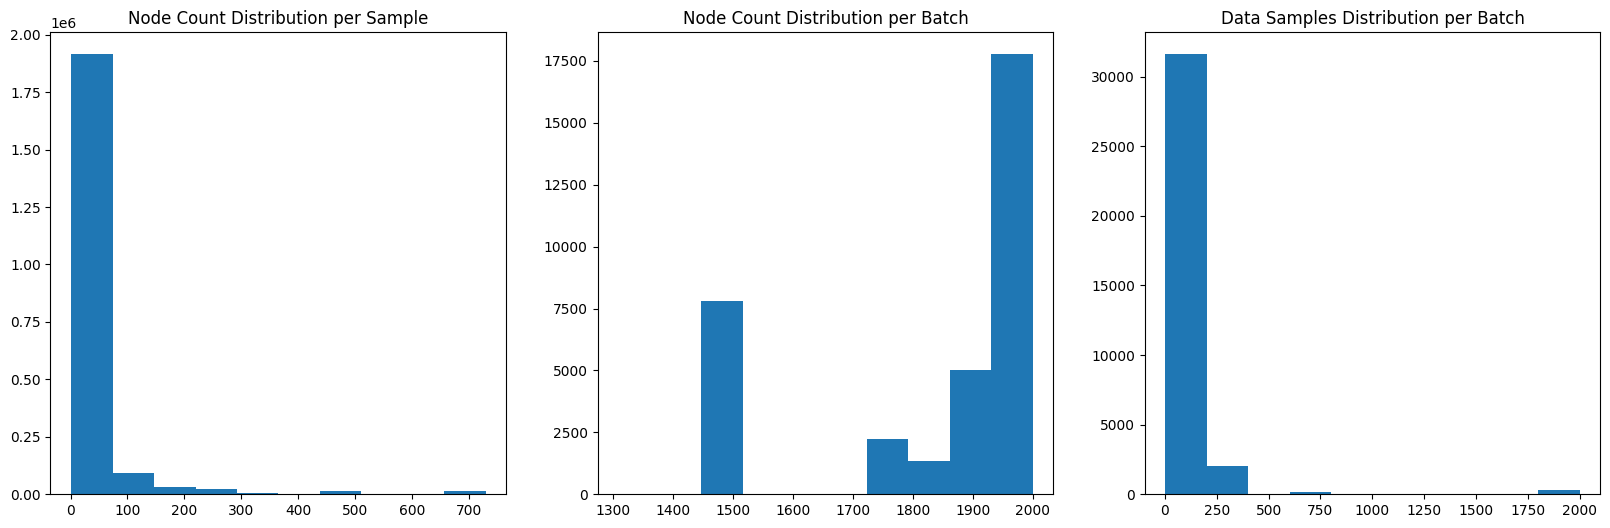

In [3]:
modelPath = os.path.join("checkpoints", "2025-06-28")
config = Config().load(os.path.join(modelPath, "config.json"))
model = InundationGCLSTMStation(config)
stateDict = torch.load(os.path.join(modelPath, "checkpoint.pt"), weights_only=True)
model.load_state_dict(stateDict)
dataset = InundationData(config)
train, test = InundationData.split(dataset, trainSplit=config.dataSplit, seed=config.seed, shuffle=False)

3659/34167 | 10.71% Complete

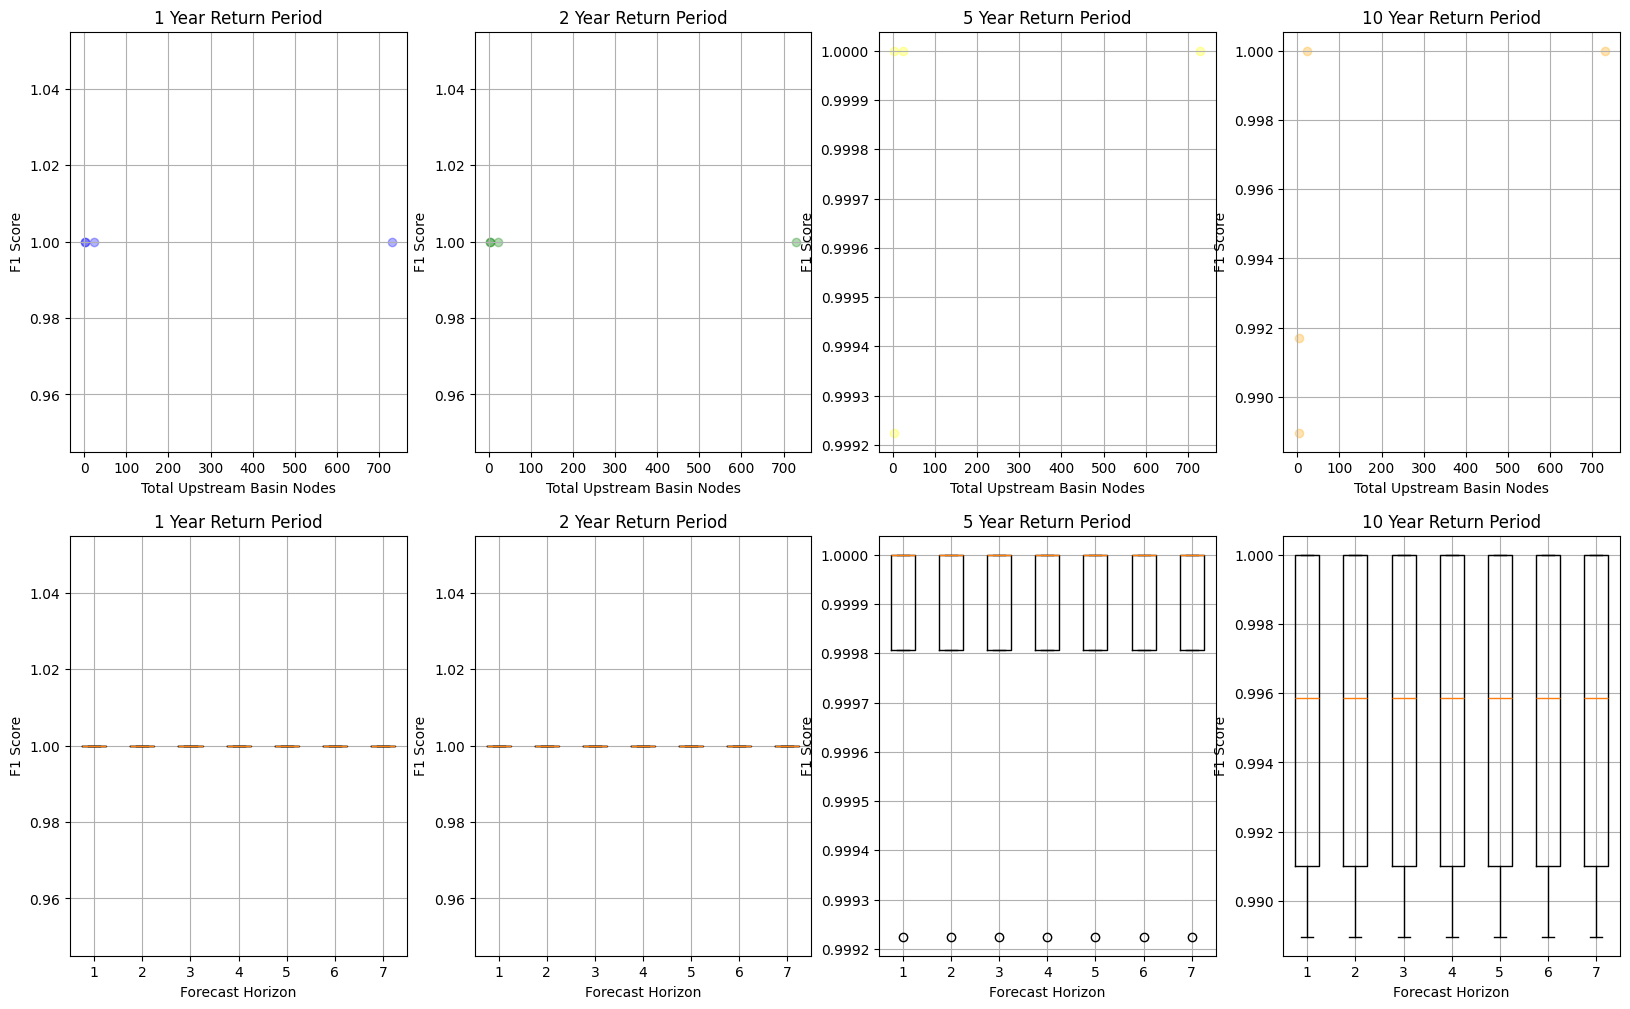

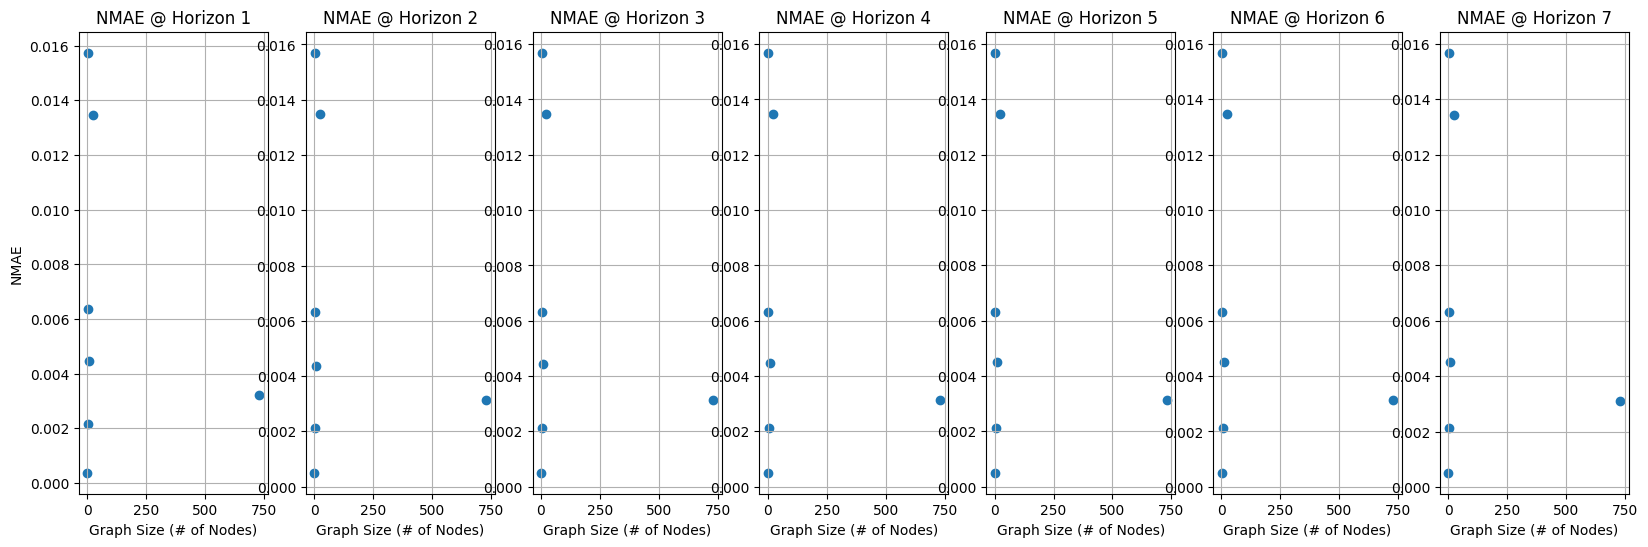

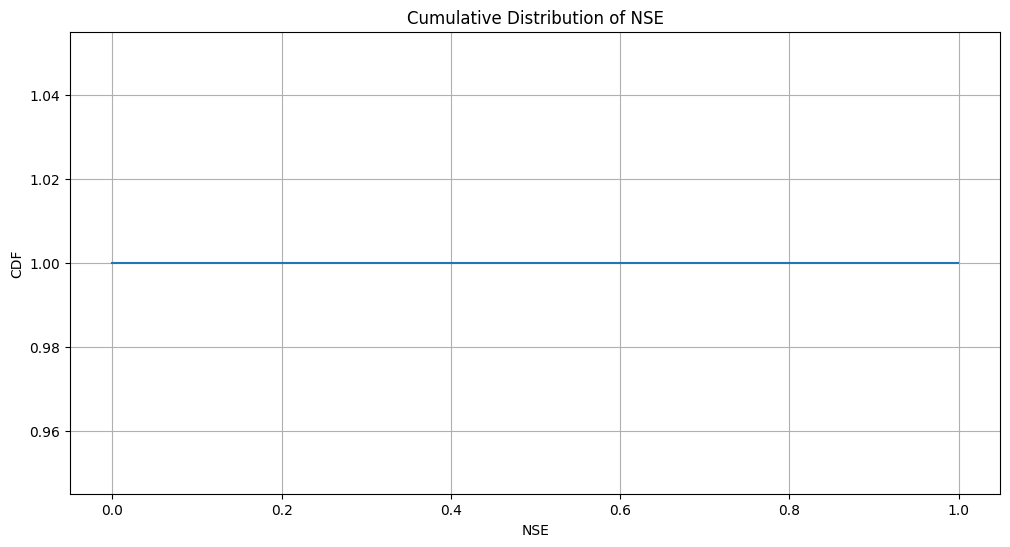

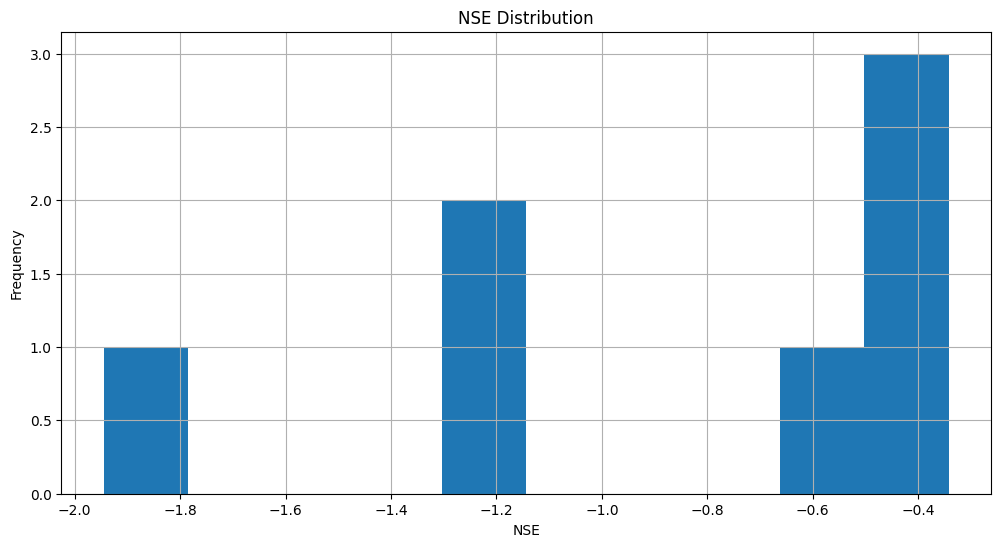

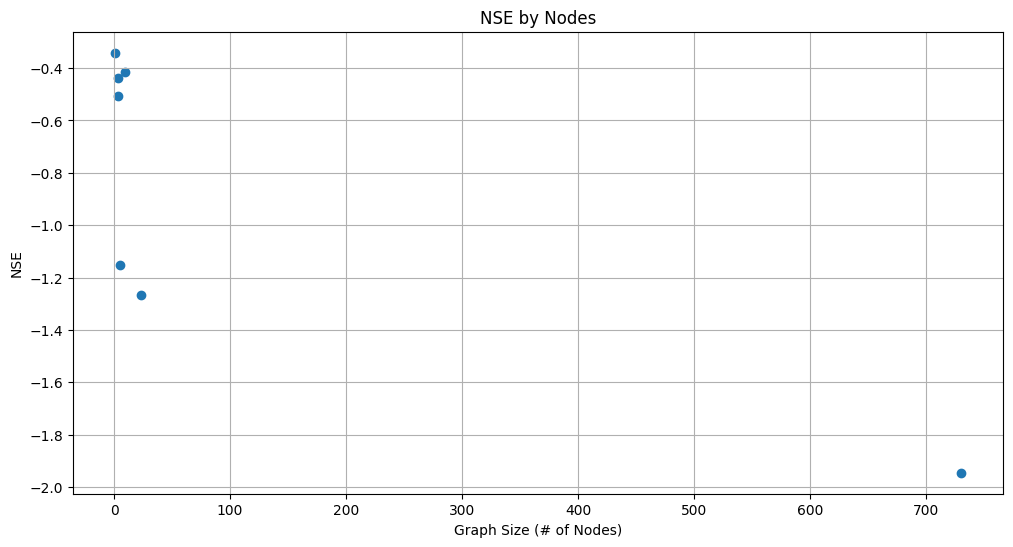

In [9]:
evalModel(config, model, test)